# Training Hello world model for Microcontrollers

In this post, we'll cover the basic tutorial for training simple regression model with tensorflow lite for for Microcontrollers(TFLM).

- author: Chanseok Kang

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (16, 10)

## Tensorflow Lite for Microcontrollers
[TensorFlow Lite for Microcontrollers](https://www.tensorflow.org/lite/microcontrollers) (TFLM for short) is designed to run machine learning models on microcontrollers and other devices with only few kilobytes of memory. For the purpose of deploying machine learning model on embedded devices, it is also called [TinyML](https://tinyml.org/home/). As you know already, Tensorflow is one of commonly-used deep learning frameworks, and from version 2.x they offer some machine learning features for embedded systems via tensorflow lite. Unlike high performance mobile processor(like cortex-A series), Microcontroller (Cortex-M series or ESP32) has low power consumptions and it can deploy in various ways of customer products, like refrigerator, wash-machine and so on.

Google introduced several supported boards for test,

- [Arduino Nano 33 BLE Sense](https://store.arduino.cc/usa/nano-33-ble-sense-with-headers) (using Arduino IDE)
- [SparkFun Edge](https://www.sparkfun.com/products/15170) (building directly from source)
- [STM32F746 Discovery kit](https://www.st.com/en/evaluation-tools/32f746gdiscovery.html) (using Mbed)
- [Adafruit EdgeBadge](https://www.adafruit.com/product/4400) (using Arduino IDE)
- [Adafruit TensorFlow Lite for Microcontrollers Kit](https://www.adafruit.com/product/4317) (using Arduino IDE)
- [Adafruit Circuit Playground Bluefruit](https://learn.adafruit.com/tensorflow-lite-for-circuit-playground-bluefruit-quickstart?view=all) (using Arduino IDE)
- [Espressif ESP32-DevKitC](https://www.espressif.com/en/products/hardware/esp32-devkitc/overview) (using ESP IDF)
- [Espressif ESP-EYE](https://www.espressif.com/en/products/hardware/esp-eye/overview) (using ESP IDF)

Here, we'll implement the simple regression model in **Sparkfun Edge**. Most of contents are covered in Pete Warden's screencast. More informations are included in his [book](https://www.oreilly.com/library/view/tinyml/9781492052036/).

> youtube: https://www.youtube.com/watch?v=8N6-WQsxwxA&t=205s

### Prerequisites for implementation
Before beginning, it requires some hardwares and basic knowledges,

- hardware
    - Sparkfun edge
    - CH340c USB-c to UART converter
    - Desktop PC for training model (or you can use google colab)
- Knowledge
    - Python
    - C/C++
    - Basic knowledge related on OS

### Hello world
Actually, "Hello world" may be the first program we faced, since it can show simple interaction between human and computer. TinyML also has simple example of "Hello world". Instead of Printing, we will build a model to generate the sine wave. So maybe our hypothesis will be like this,

$$ \tilde{H(x)} = \sin(x) $$

At first, we load the required packages,

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math

plt.rcParams['figure.figsize'] = (16, 10)
plt.rc('font', size=15)

# define random seed for reproducibility
np.random.seed(1) # numpy seed
tf.random.set_seed(1) # tensorflow global random seed

In [ ]:
print('Numpy: {}'.format(np.__version__))
print('Tensorflow: {}'.format(tf.__version__))

Numpy: 2.0.2
Tensorflow: 2.18.0


To train the model, it requires a sort of data, namely training data. In our case, we will sample the random data from numpy and generate the actual output from known model(the sine function)

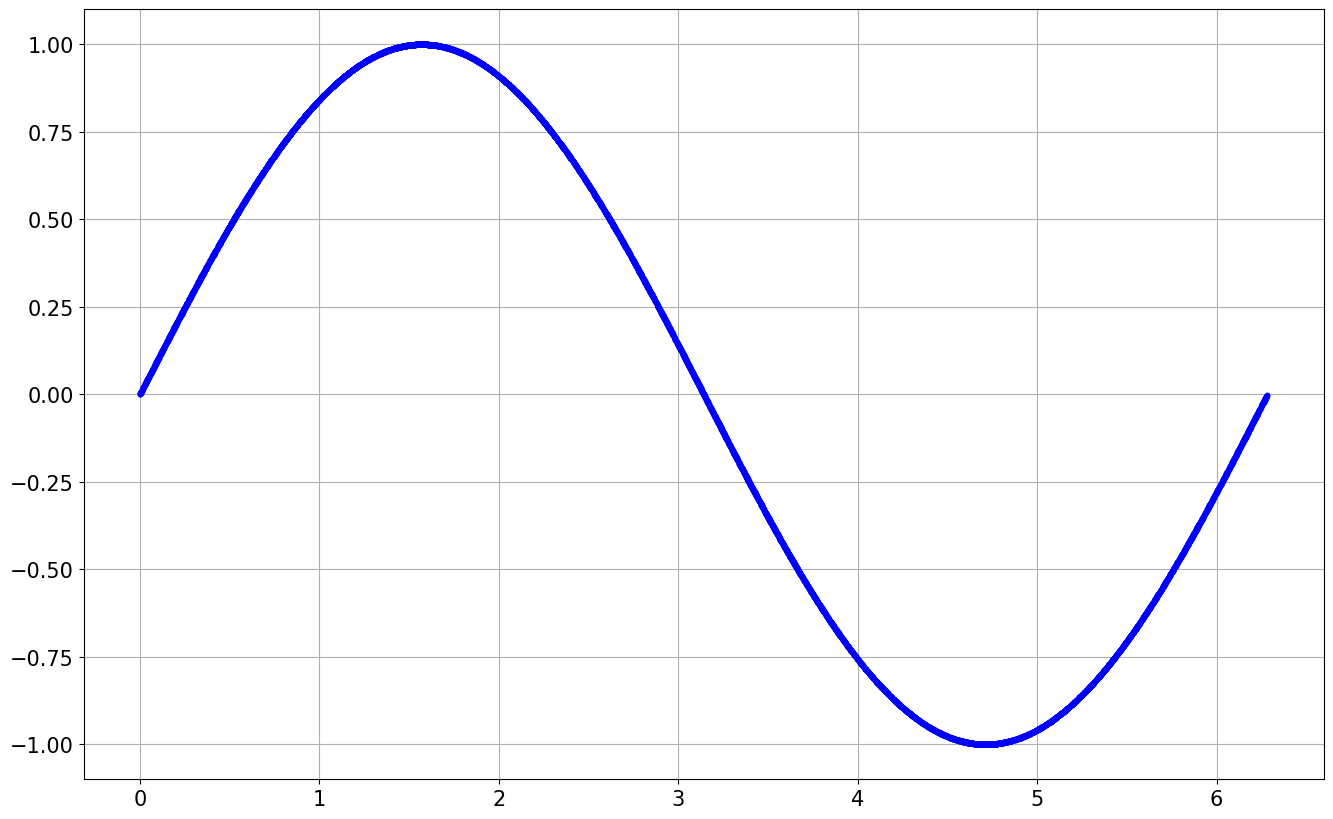

In [ ]:
# Generate a uniformly distributed set of random numbers in the range from
# 0 to 2π, which covers a complete sine wave oscillation
X = np.random.uniform(low=0, high=2*np.pi, size=10000).astype(np.float32)

# Shuffle the values to guarantee they're not in order
np.random.shuffle(X)

# Calculate the corresponding sine values
y = np.sin(X).astype(np.float32)

# Plot our data. The 'b.' argument tells the library to print blue dots.
plt.plot(X, y, 'b.')
plt.grid()
plt.show()

But this data doesn't reflect the real-world data, because there is no variation of distribution in dataset, also known as noise. We can add random data for each x, so it makes to seem more randomly distributed.

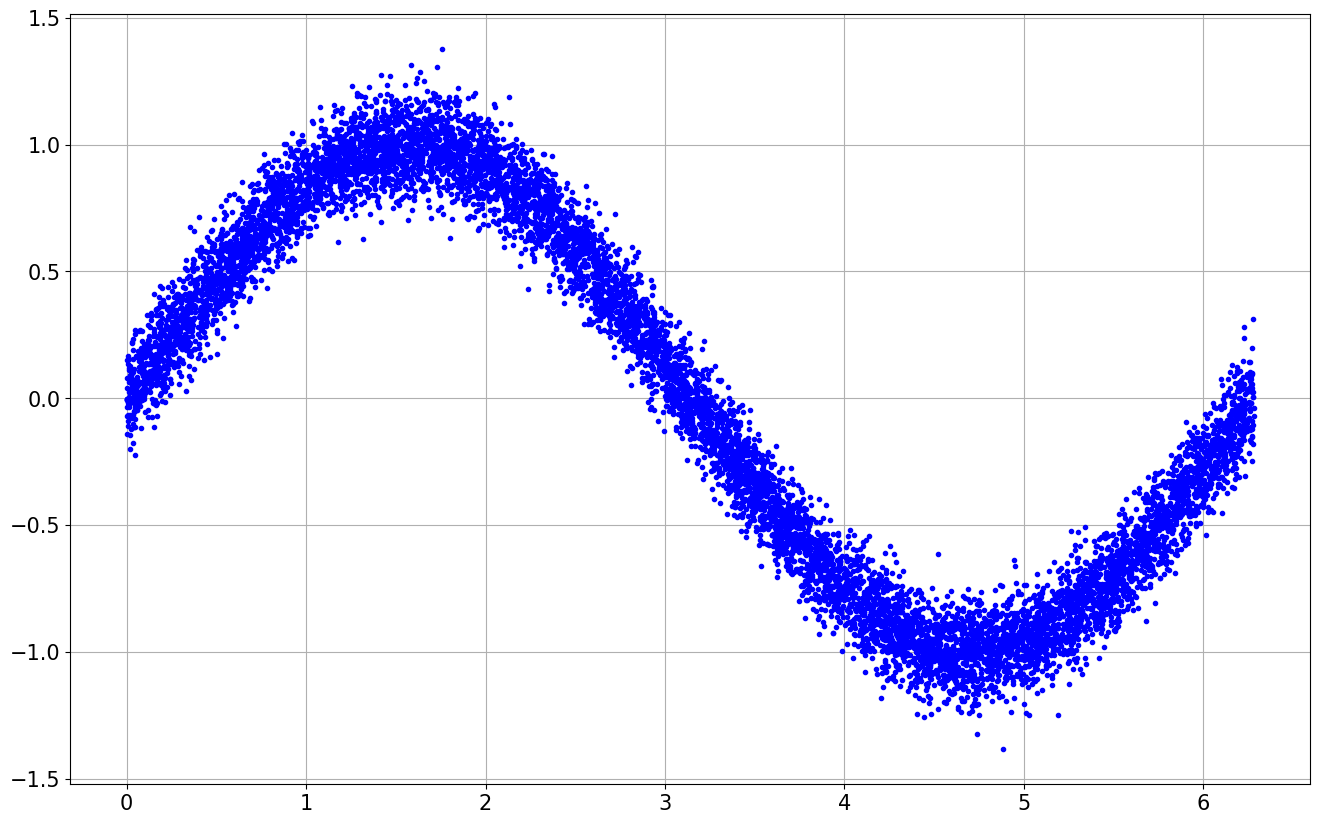

In [ ]:
# Add a small random number to each y value
y += 0.1 * np.random.randn(*y.shape)

# Plot our data
plt.plot(X, y, 'b.')
plt.grid()
plt.show()

Through this, we expect that the model is approximated with sinusoid curve if it is well trained.

To use it for training, we are going to preprocess the data. We'll split it with following proportions,
    
- Train data: 60%
- Validation data: 20%
- Test data: 20%

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

print('Número de amostras de treinamento:', X_train.shape[0])
print('Número de amostras de validação:',X_val.shape[0])
print('Número de amostras de teste:',X_test.shape[0])

Número de amostras de treinamento: 6000
Número de amostras de validação: 2000
Número de amostras de teste: 2000


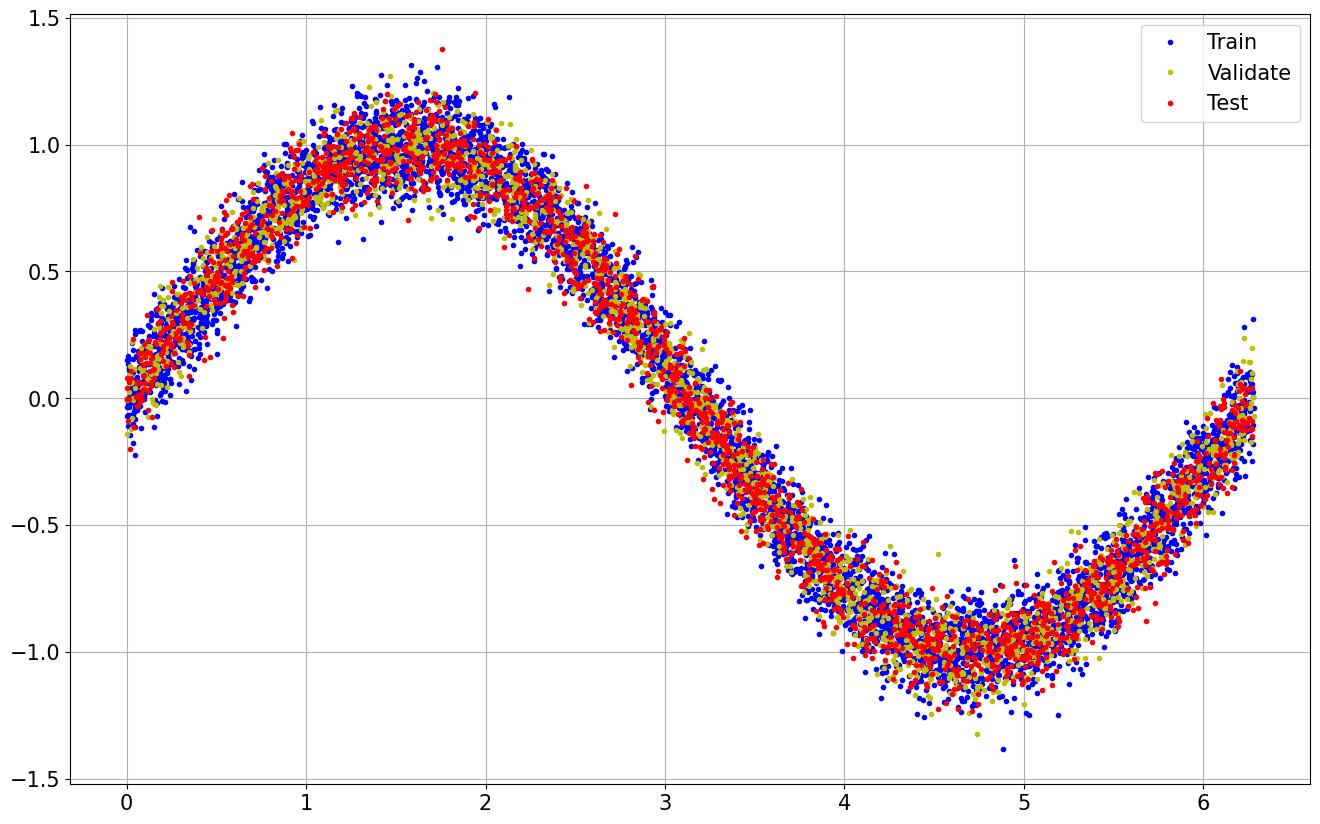

In [ ]:
# Plot the data in each partition in different colors:
plt.plot(X_train, y_train, 'b.', label="Train")
plt.plot(X_val, y_val, 'y.', label="Validate")
plt.plot(X_test, y_test, 'r.', label="Test")
plt.legend()
plt.grid()
plt.show()

To train the model, we will use sequential model in tensorflow-keras, and add two Dense layer. Then we will add adam optimizer, and set mean squared error for loss.

In [ ]:
model = tf.keras.Sequential(name='sine')
model.add(tf.keras.layers.Input(shape=(1, )))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(1))

model.summary()

Model: "sine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

Now, it's time to train the model.

In [ ]:
history = model.fit(X_train, y_train, epochs=500, batch_size=64, validation_data=(X_val, y_val))

Epoch 1/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.6018 - mae: 0.6933 - val_loss: 0.4150 - val_mae: 0.5604
Epoch 2/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3975 - mae: 0.5442 - val_loss: 0.3191 - val_mae: 0.4883
Epoch 3/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3097 - mae: 0.4788 - val_loss: 0.2574 - val_mae: 0.4394
Epoch 4/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2523 - mae: 0.4346 - val_loss: 0.2180 - val_mae: 0.4045
Epoch 5/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2155 - mae: 0.4050 - val_loss: 0.1941 - val_mae: 0.3811
Epoch 6/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1933 - mae: 0.3846 - val_loss: 0.1803 - val_mae: 0.3651
Epoch 7/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1806 - mae: 0.3704 - val_loss: 0.1726 - val_mae: 0.3549
Epoch 8/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1734 - mae: 0.3607 - val_loss: 0.1683 - val_mae: 0.3479
Epoch 9/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.16

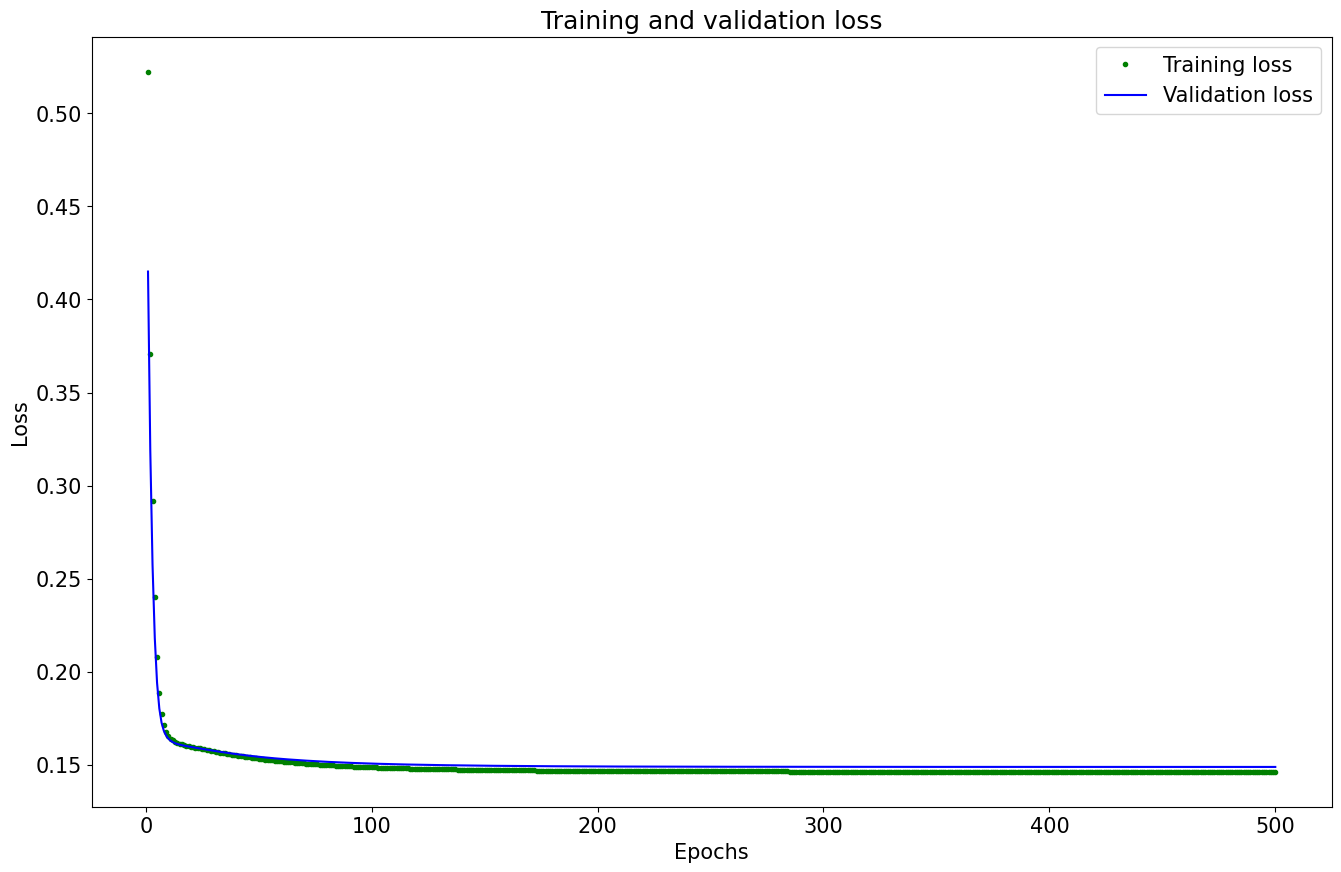

In [ ]:
# Draw a graph of the loss, which is the distance between
# the predicted and actual values during training and validation.
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

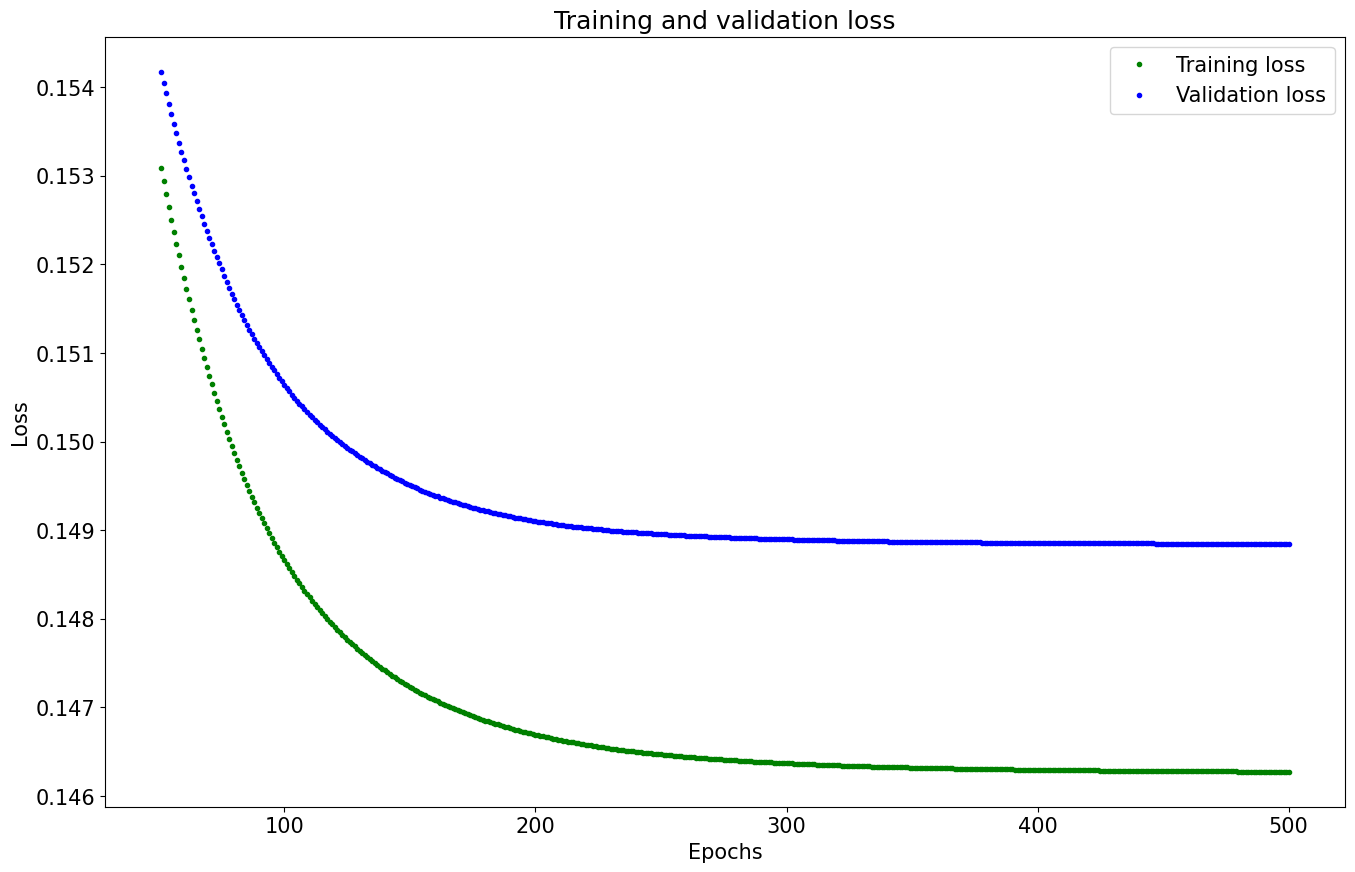

In [ ]:
# Exclude the first few epochs so the graph is easier to read
SKIP = 50

plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1502 - mae: 0.3011
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


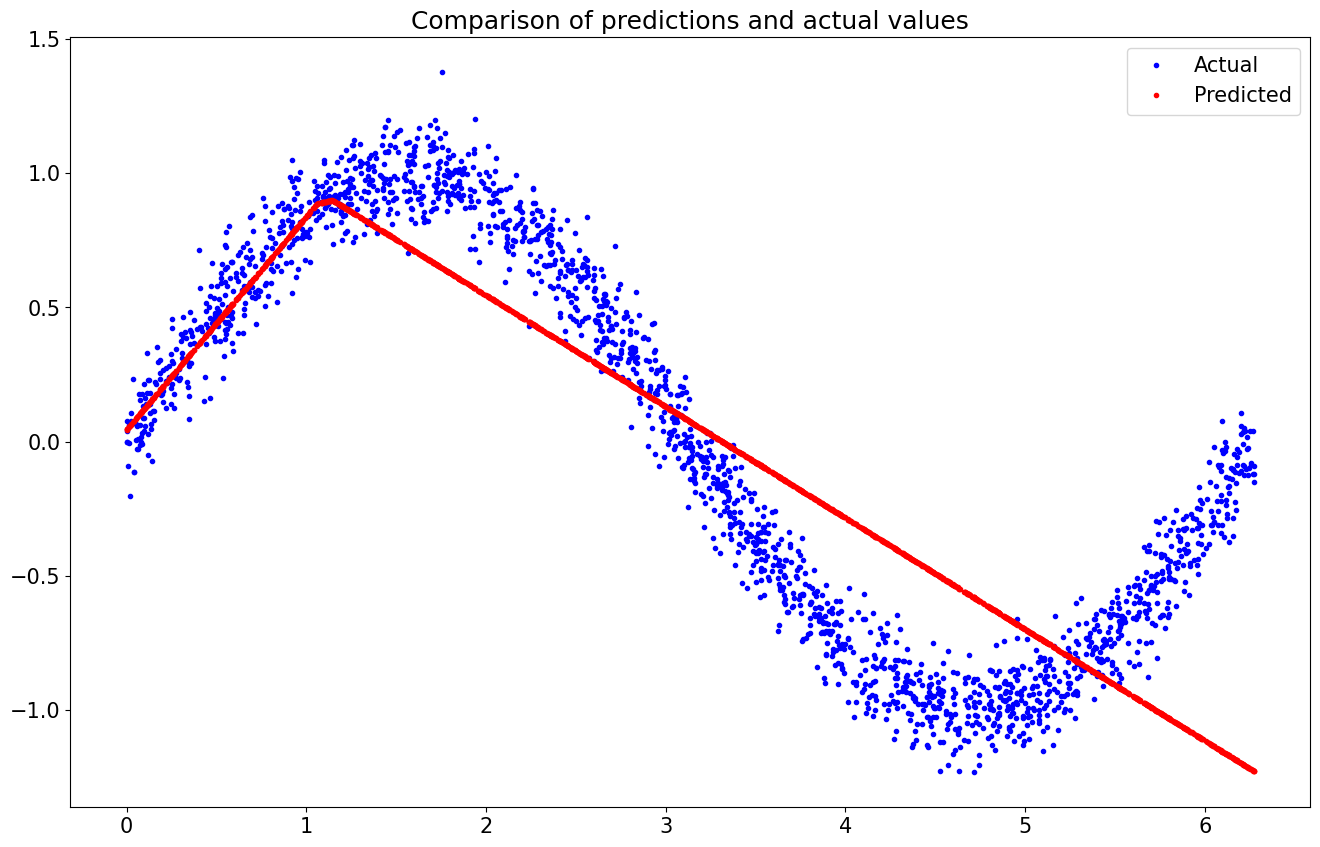

In [ ]:
# Calculate and print the loss on our test dataset
loss = model.evaluate(X_test, y_test)

# Make predictions based on our test dataset
predictions = model.predict(X_test)

# Graph the predictions against the actual values
plt.clf()
plt.title('Comparison of predictions and actual values')
plt.plot(X_test, y_test, 'b.', label='Actual')
plt.plot(X_test, predictions, 'r.', label='Predicted')
plt.legend()
plt.show()

## Increasing the number of layers

In [ ]:
model_2 = tf.keras.Sequential(name='sine2')

# Input layer.
model_2.add(tf.keras.layers.Input(shape=(1,)))

# First layer takes a scalar input and feeds it through 16 "neurons". The
# neurons decide whether to activate based on the 'relu' activation function.
model_2.add(tf.keras.layers.Dense(16, activation='relu'))

# The new second layer may help the network learn more complex representations
model_2.add(tf.keras.layers.Dense(16, activation='relu'))

# Final layer is a single neuron, since we want to output a single value
model_2.add(tf.keras.layers.Dense(1))

# Compile the model using a standard optimizer and loss function for regression
model_2.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_2.summary()

Model: "sine2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model_2.fit(X_train, y_train, epochs=500, batch_size=64, validation_data=(X_val, y_val))

Epoch 1/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3957 - mae: 0.5375 - val_loss: 0.2595 - val_mae: 0.4374
Epoch 2/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2350 - mae: 0.4187 - val_loss: 0.1662 - val_mae: 0.3485
Epoch 3/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1582 - mae: 0.3421 - val_loss: 0.1379 - val_mae: 0.3031
Epoch 4/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1353 - mae: 0.3009 - val_loss: 0.1295 - val_mae: 0.2829
Epoch 5/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1277 - mae: 0.2816 - val_loss: 0.1250 - val_mae: 0.2728
Epoch 6/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1232 - mae: 0.2718 - val_loss: 0.1209 - val_mae: 0.2658
Epoch 7/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1189 - mae: 0.2649 - val_loss: 0.1165 - val_mae: 0.2591
Epoch 8/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1143 - mae: 0.2582 - val_loss: 0.1116 - val_mae: 0.2521
Epoch 9/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.10

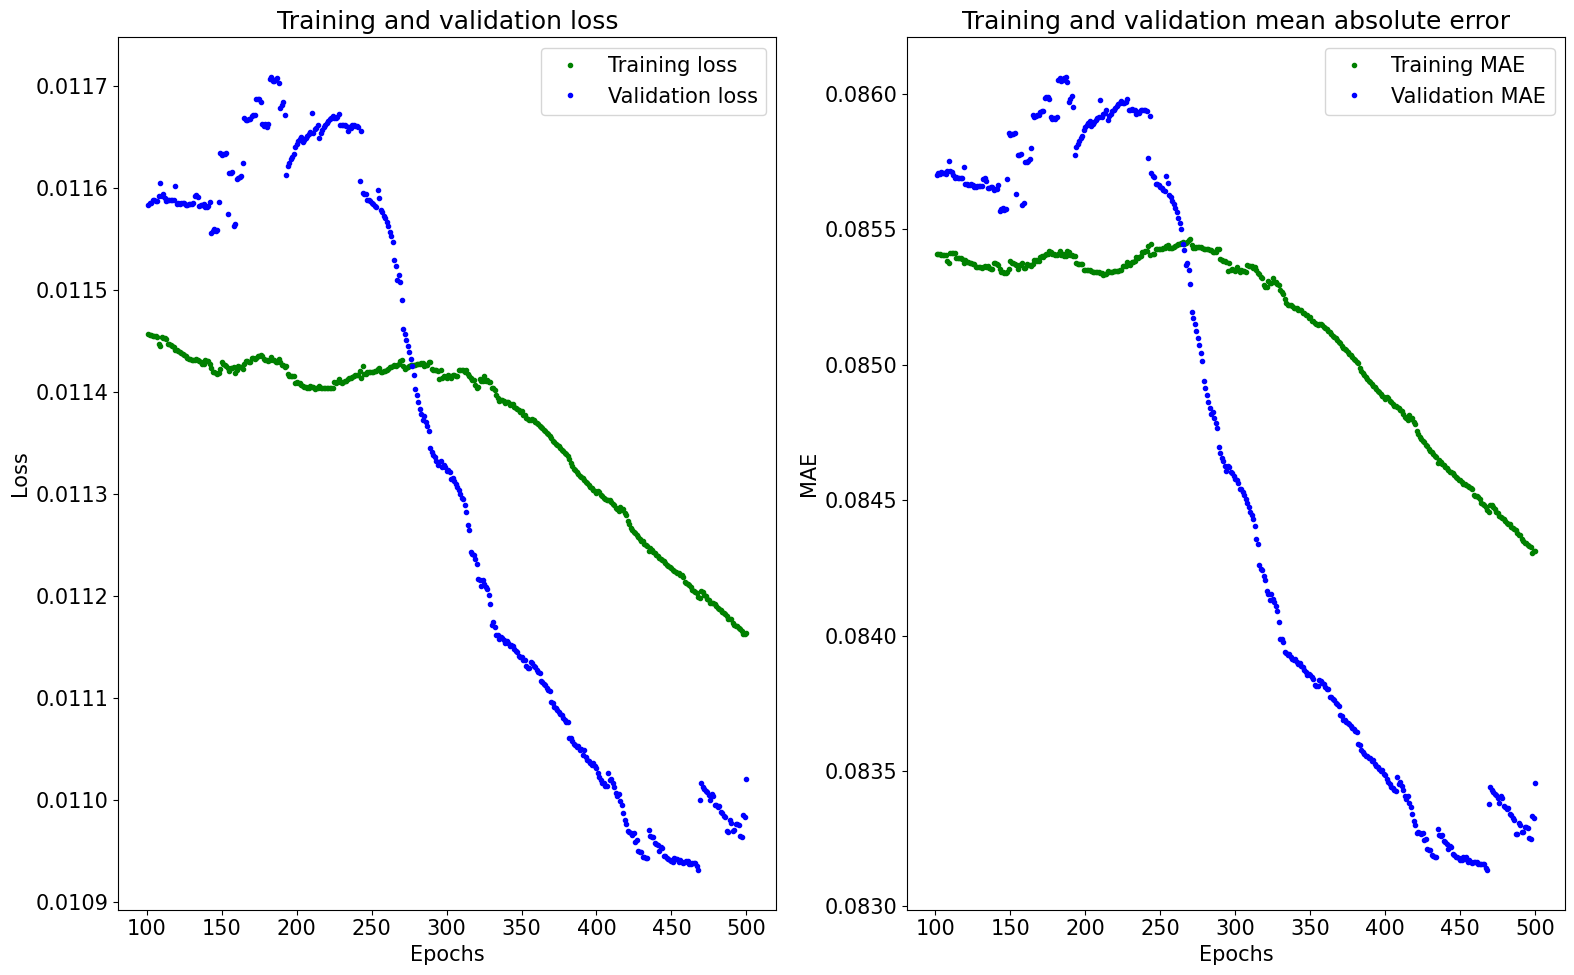

In [ ]:
# Draw a graph of the loss, which is the distance between
# the predicted and actual values during training and validation.
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

# Exclude the first few epochs so the graph is easier to read
SKIP = 100

plt.figure()
plt.subplot(1, 2, 1)

plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)

# Draw a graph of mean absolute error, which is another way of
# measuring the amount of error in the prediction.
mae = history.history['mae']
val_mae = history.history['val_mae']

plt.plot(epochs[SKIP:], mae[SKIP:], 'g.', label='Training MAE')
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b.', label='Validation MAE')
plt.title('Training and validation mean absolute error')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0114 - mae: 0.0849
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


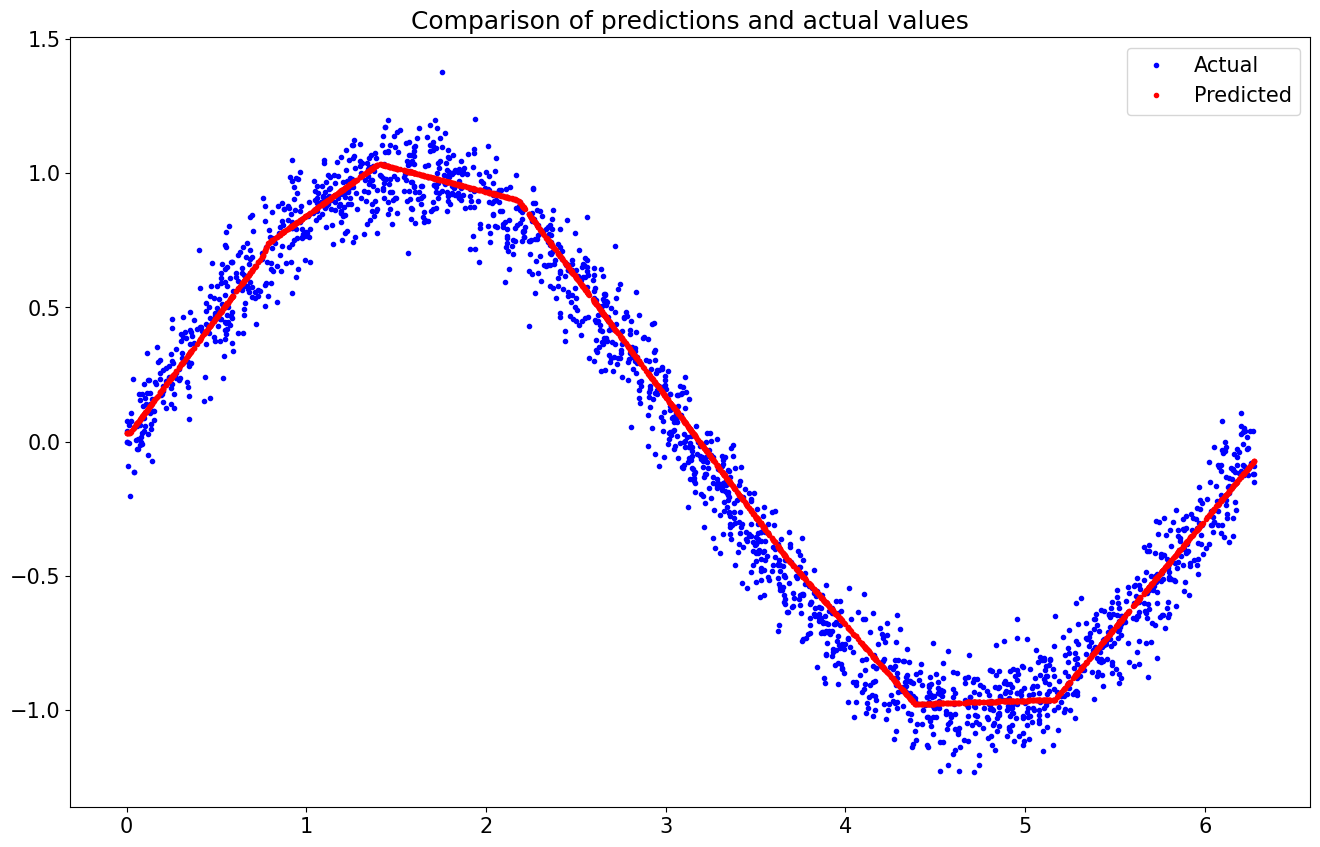

In [ ]:
# Calculate and print the loss on our test dataset
loss = model_2.evaluate(X_test, y_test)

# Make predictions based on our test dataset
predictions = model_2.predict(X_test)

# Graph the predictions against the actual values
plt.clf()
plt.title('Comparison of predictions and actual values')
plt.plot(X_test, y_test, 'b.', label='Actual')
plt.plot(X_test, predictions, 'r.', label='Predicted')
plt.legend()
plt.show()

## Converting and saving the models

In [ ]:
import os
MODEL_DIR = './models/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

### Saving original model

In [ ]:
model_2.save(MODEL_DIR+'model_2_original.keras')

### Without quantization

In [ ]:
# Instantiate a model converter.
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)

# Convert the model to the TensorFlow Lite format without quantization
model_no_quant_tflite = converter.convert()

# Save the model to disk
with open(MODEL_DIR + 'model_2_no_quant.tflite', "wb") as f:
  f.write(model_no_quant_tflite)

Saved artifact at '/tmp/tmp9zo72na5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137722790012752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790013328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790012944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790014480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790014672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790016400: TensorSpec(shape=(), dtype=tf.resource, name=None)


### With quantization

Creating **integer** (input and output are not quantized) models is a common use case for LiteRT for Microcontrollers and Coral Edge TPUs.

In [ ]:
# Convert the model to the TensorFlow Lite format with quantization
# Ajuda a quantizar as ativações definido o intervalo dinâmico de cada uma delas.
def representative_dataset():
    for i in range(500):
        yield([X_train[i].reshape(1, 1)])

# Set the optimization flag.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Enforce full-int8 quantization (including inputs/outputs)
#converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
#converter.inference_input_type = tf.int8  # or tf.uint8
#converter.inference_output_type = tf.int8  # or tf.uint8

# Provide a representative dataset to ensure we quantize correctly.
converter.representative_dataset = representative_dataset

# Apply the conversion.
model_tflite = converter.convert()

# Save the model to disk
open(MODEL_DIR + 'model_2_quant.tflite', "wb").write(model_tflite)

Saved artifact at '/tmp/tmpaen7g6aj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137722790012752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790013328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790012944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790014480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790014672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137722790016400: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


3744

### Comparing sizes

In [ ]:
model_original_size = os.path.getsize(MODEL_DIR + 'model_2_original.keras')
print("Original model is %d bytes" % model_original_size)

model_no_quant_size = os.path.getsize(MODEL_DIR + 'model_2_no_quant.tflite')
print("Non-quantized model is %d bytes" % model_no_quant_size)

model_quant_size = os.path.getsize(MODEL_DIR + 'model_2_quant.tflite')
print("Quantized model is %d bytes" % model_quant_size)

difference = model_no_quant_size - model_quant_size
print("Difference is %d bytes" % difference)

Original model is 29230 bytes
Non-quantized model is 3116 bytes
Quantized model is 3744 bytes
Difference is -628 bytes


**OBS**.: Possíveis causas para o aumento do tamanho do modelo quantizado em relação ao não quantizado:

+ Se o modelo original tem poucas camadas, a adição de metadados pode superar a economia de espaço obtida pela conversão de float32 para int8.
+ O formato FlatBuffers armazena os dados em um layout otimizado. Às vezes, a quantização altera a estrutura interna, adicionando alinhamento ou padding para eficiência em runtime.

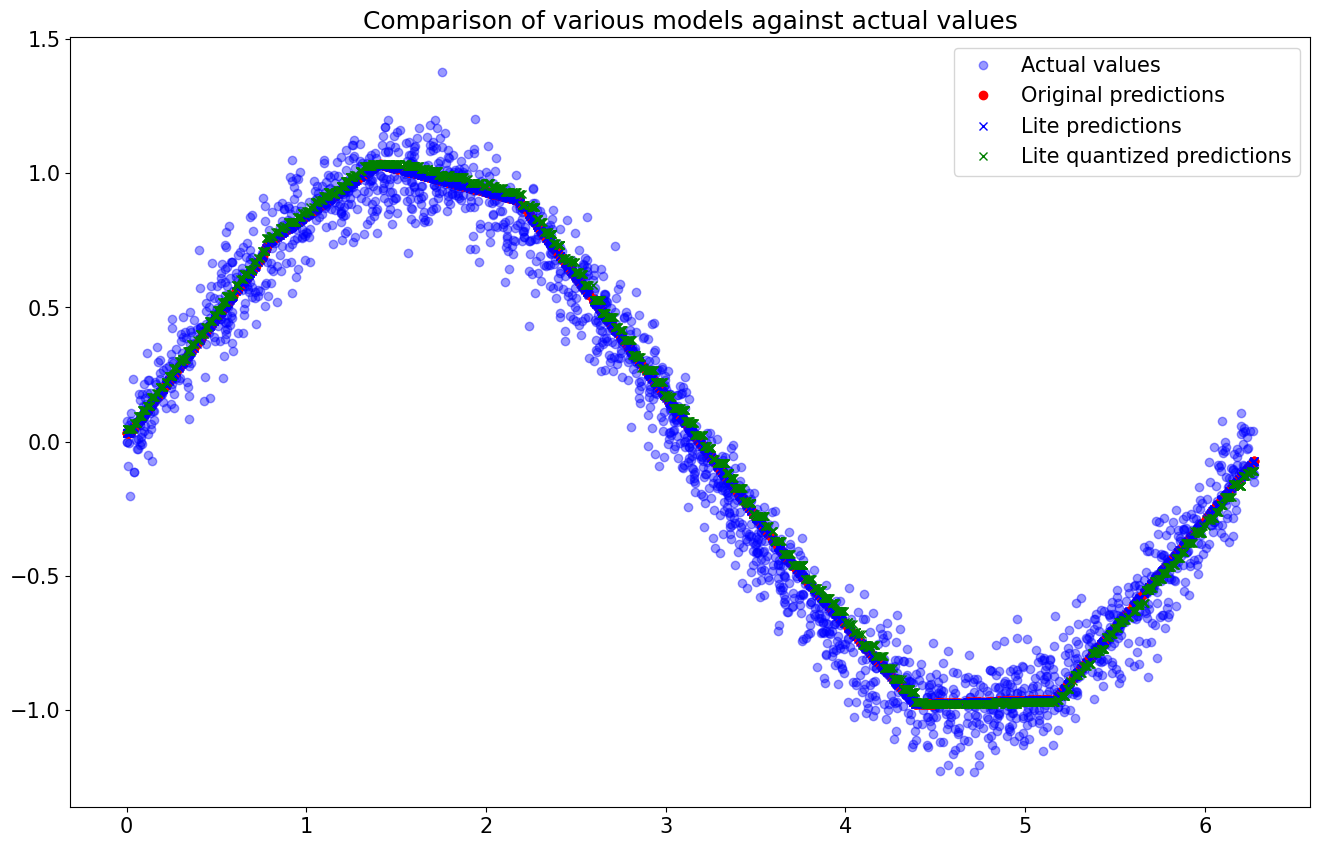

In [ ]:
# Instantiate an interpreter for each model.
# Interpreter interface for running TensorFlow Lite models.
model_no_quant = tf.lite.Interpreter(MODEL_DIR + 'model_2_no_quant.tflite')
model_quant = tf.lite.Interpreter(MODEL_DIR + 'model_2_quant.tflite')

# Allocate memory for each model
model_no_quant.allocate_tensors()
model_quant.allocate_tensors()

# Get the input and output tensors so we can feed in values and get the results
model_no_quant_input = model_no_quant.tensor(model_no_quant.get_input_details()[0]["index"])
model_no_quant_output = model_no_quant.tensor(model_no_quant.get_output_details()[0]["index"])

model_quant_input = model_quant.tensor(model_quant.get_input_details()[0]["index"])
model_quant_output = model_quant.tensor(model_quant.get_output_details()[0]["index"])

# Create empty arrays to store the results
model_no_quant_predictions = np.empty(X_test.size)
model_quant_predictions = np.empty(X_test.size)

# Run each model's interpreter for each value and store the results in arrays
for i in range(X_test.size):
    model_no_quant_input().fill(X_test[i])
    model_no_quant.invoke()
    model_no_quant_predictions[i] = model_no_quant_output()[0].item()

    model_quant_input().fill(X_test[i])
    model_quant.invoke()
    model_quant_predictions[i] = model_quant_output()[0].item()

# See how they line up with the data
plt.clf()
plt.title('Comparison of various models against actual values')
plt.plot(X_test, y_test, 'bo', label='Actual values', alpha=0.4)
plt.plot(X_test, predictions, 'ro', label='Original predictions')
plt.plot(X_test, model_no_quant_predictions, 'bx', label='Lite predictions')
plt.plot(X_test, model_quant_predictions, 'gx', label='Lite quantized predictions')
plt.legend()
plt.show()

## Generate a TensorFlow Lite for Microcontrollers Model
Convert the TensorFlow Lite quantized model into a C source file that can be loaded by TensorFlow Lite for Microcontrollers.

In [ ]:
!xxd -i {MODEL_DIR + 'model_2_quant.tflite'} > {MODEL_DIR + 'model_2_quant.cc'}

In [ ]:
!cat {MODEL_DIR + 'model_2_quant.cc'}

unsigned char __models_model_2_quant_tflite[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x8c, 0x00, 0x00, 0x00, 0x0c, 0x01, 0x00, 0x00,
  0x00, 0x04, 0x00, 0x00, 0x10, 0x04, 0x00, 0x00, 0x14, 0x0e, 0x00, 0x00,
  0x03, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00,
  0xae, 0xfb, 0xff, 0xff, 0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x3c, 0x00, 0x00, 0x00, 0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76,
  0x69, 0x6e, 0x67, 0x5f, 0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x68, 0xff, 0xff, 0xff,
  0x0b, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00,
  0x6f, 0x75, 0x74, 0x70, 0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x86, 0xfc, 